In [1]:
#Section 0 - Environment Setting up
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from matplotlib.patches import Patch

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (mean_squared_error, f1_score, classification_report, ConfusionMatrixDisplay)

# Global plot style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.figsize':(13,5), 'font.size':12, 'axes.labelsize':12})
print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
# Section 1 - Load, Parse and Merge Datasets

# read Data
energy = pd.read_csv('energy_data.csv')
weather = pd.read_csv('weather_data.csv')

# Preview data - Energy Dataset
print("===== Energy Data =====")
print(energy.info())
print(energy.head())
print("===== Energy Missing Values =====")
print(energy.isnull().sum())

# Preview data - Weather Dataset
print("===== Weather Data =====")
print(weather.info())
print(energy.head())
print("===== Weather Missing Values =====")
print(weather.isnull().sum())

===== Energy Data =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17520 entries, 0 to 17519
Data columns (total 18 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Date & Time                      17520 non-null  object 
 1   use [kW]                         17520 non-null  float64
 2   gen [kW]                         17520 non-null  float64
 3   Grid [kW]                        17520 non-null  float64
 4   AC [kW]                          17520 non-null  float64
 5   Furnace [kW]                     17520 non-null  float64
 6   Cellar Lights [kW]               17520 non-null  float64
 7   Washer [kW]                      17520 non-null  float64
 8   First Floor lights [kW]          17520 non-null  float64
 9   Utility Rm + Basement Bath [kW]  17520 non-null  float64
 10  Garage outlets [kW]              17520 non-null  float64
 11  MBed + KBed outlets [kW]         17520 non-null  float64

# Data Preview Key Points

## From the above
1. **Energy dataset** - `Date & Time` is stored as `object` (string). Needs to be converted to `datetime`.
2. **Energy dataset** - No missing values detected across all columns.
3. **Weather dataset** - `time` is stored as `int64` (Unix timestamp in seconds). Needs to be converted to `datetime` using `unit='s'`.
4. **Weather dataset** - `icon` and `summary` are categorical text columns with no predictive value for modeling. Will be dropped.
5. **Weather dataset** - `cloudCover` has 1,470 missing values (~16.8% of rows). Will be imputed with the column mean.

## From directly looking at datasets
1. The records in the Energy dataset were collected per 30 mins. There are 48 records per day.
2. The records in the Weather dataset were collected per hour. There are 24 records per day. 

In [3]:
# Convert 'Data & Time' from string to datetime
energy['datetime'] = pd.to_datetime(energy['Date & Time'])

# Extract date only for daily grouping
energy['date'] = energy['datetime'].dt.date

#Convert 'time' to datetime
weather['datetime'] = pd.to_datetime(weather['time'], unit='s')
weather['date'] = weather['datetime'].dt.date

# Drop string columns with no predictive value
weather.drop(columns=['icon','summary'], inplace=True)

#Impute missing cloudCover values with column mean
weather['cloudCover'] = weather['cloudCover'].fillna(weather['cloudCover'].mean())

print("Missing values after imputation:", weather['cloudCover'].isnull().sum())

Missing values after imputation: 0


In [4]:
# Aggregate to Daily 

# Energy: sum all 30-min readings per day to total daily kWh
energy_daily = (energy
               .groupby('date')['use [kW]']
               .sum()
               .reset_index()
               .rename(columns={'use [kW]': 'daily_use_kW'}))

# Weather: average all hourly readings per day
feature_cols=['temperature', 'humidity', 'visibility', 'pressure',
             'windSpeed', 'cloudCover', 'windBearing',
             'precipIntensity', 'dewPoint', 'precipProbability']
weather_daily = (weather
                .groupby('date')[feature_cols]
                .mean()
                .reset_index())

# Merge on date
merged = pd.merge(energy_daily, weather_daily, on='date', how='inner')
merged['date'] = pd.to_datetime(merged['date'])

print('Merged shape:', merged.shape)
print(merged.head())

Merged shape: (365, 12)
        date  daily_use_kW  temperature  humidity  visibility     pressure  \
0 2014-01-01     65.013592    20.110833  0.556667    9.970000  1025.395000   
1 2014-01-02     32.305336    16.382500  0.784583    3.834583  1023.465833   
2 2014-01-03     31.164468     6.256667  0.680833    4.509167  1014.428750   
3 2014-01-04     45.287782     2.711667  0.617083    9.822917  1030.096250   
4 2014-01-05     36.316643    17.654167  0.682083    9.134583  1025.275000   

   windSpeed  cloudCover  windBearing  precipIntensity   dewPoint  \
0   6.820417    0.035749   252.291667         0.000000   6.362083   
1   7.433750    0.219149    53.458333         0.002004  10.737083   
2  12.828333    0.160151   207.333333         0.002029  -2.337500   
3   5.248333    0.001667   240.166667         0.000000  -8.352083   
4   3.417083    0.026830   208.958333         0.000033   8.615000   

   precipProbability  
0           0.000000  
1           0.074583  
2           0.080000  


In [5]:
# Section 2 - Train/Test Split

#Define target value
target_col = 'daily_use_kW'

#Split: Train on Jan. - Nov. Test on Dec.
train = merged[merged['date'].dt.month != 12].copy()
test = merged[merged['date'].dt.month == 12].copy()

X_train = train[feature_cols]
y_train = train[target_col]

X_test = test[feature_cols]
y_test = test[target_col] 

print("Training set size:", X_train.shape, "(Jan. - Nov. 2014)")
print("Test set size:", X_test.shape, "(Dec. 2024)")

Training set size: (334, 10) (Jan. - Nov. 2014)
Test set size: (31, 10) (Dec. 2024)


In [6]:
# Section 3 - Linear Regression

# Scale features: StandardScaler normalizes each feature to mean=0, std=1
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the model
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# Predict December energy usage
y_pred_lr = lr_model.predict(X_test_scaled)

# Evaluation: calculate RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
print(f"RMSE: {rmse:.4f} kWh")

# CSV dump
lr_csv = pd.DataFrame({
    'date': test['date'].dt.strftime('%Y-%m-%d'),
    'predicted_use_kW': y_pred_lr
})
lr_csv.to_csv('linear_regression_predictions.csv', index=False)
print("Saved: linear_regression_predictions.csv")

RMSE: 8.5381 kWh
Saved: linear_regression_predictions.csv


In [7]:
print("y_test values:", y_test.values)
print("y_pred values:", y_pred_lr)

y_test values: [30.55001    31.74885722 28.77323333 39.48449111 33.34250278 36.47015333
 26.486585   23.01398    27.95435111 37.422625   35.18271167 24.20908834
 20.45544    19.82120278 41.91252611 20.71216333 21.80212278 19.836075
 32.80281889 34.29628722 21.05837611 27.36202666 19.38713611 27.68224556
 40.26813222 44.5634     35.04612667 37.69582445 28.67592944 31.51431278
 28.67449833]
y_pred values: [27.99309087 30.07266898 19.51716003 30.45304077 23.12027318 22.68990691
 20.22029249 23.29233425 21.91524938 23.06316296 20.48421253 17.7665756
 24.02609765 25.63505934 27.39739451 15.171511   21.58797993 21.87533811
 24.01120345 24.75665247 15.03505414 11.85273233 17.10161203 19.8358684
 29.09897366 34.37262256 28.47270775 25.45932632 29.94207975 30.35468143
 24.11364216]


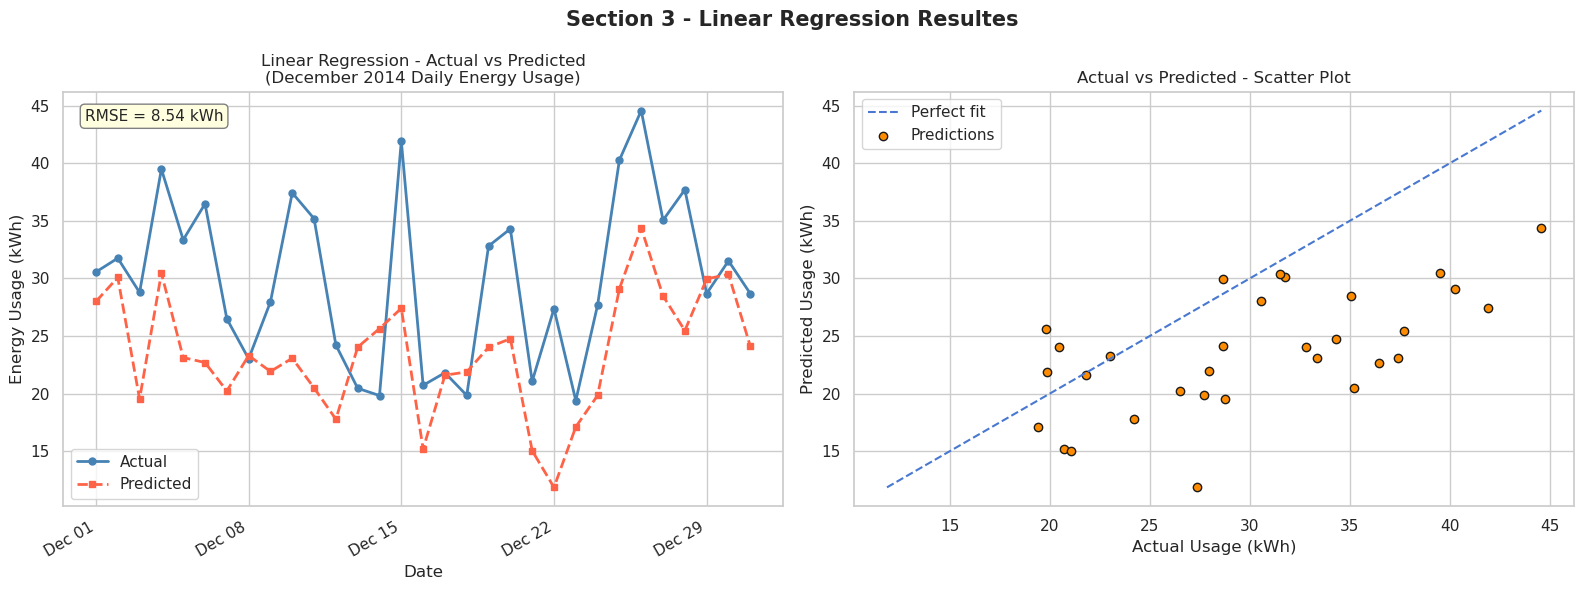

In [8]:
# Linear Regression Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Actual vs Predicted over December
axes[0].plot(test['date'].values, y_test.values,
            'o-', color='steelblue', lw=2, ms=5, label="Actual")
axes[0].plot(test['date'].values, y_pred_lr,
           's--', color='tomato', lw=2, ms=5, label='Predicted')
axes[0].set_title('Linear Regression - Actual vs Predicted\n(December 2014 Daily Energy Usage)')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Energy Usage (kWh)')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
axes[0].xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))
plt.setp(axes[0].xaxis.get_majorticklabels(),rotation=30, ha='right')
axes[0].legend()
axes[0].annotate(f'RMSE = {rmse:.2f} kWh', xy=(0.03, 0.93),
                xycoords="axes fraction", fontsize=11,
                bbox=dict(boxstyle='round, pad=0.3', fc='lightyellow', ec='gray'))

# Plot 2: Scatter plot
mn = min(y_test.min(), y_pred_lr.min())
mx = max(y_test.max(), y_pred_lr.max())
axes[1].plot([mn, mx], [mn, mx], 'b--', lw=1.5, label='Perfect fit')
axes[1].scatter(y_test, y_pred_lr, color='darkorange', edgecolors='k', label="Predictions")

axes[1].set_title('Actual vs Predicted - Scatter Plot')
axes[1].set_xlabel('Actual Usage (kWh)')
axes[1].set_ylabel('Predicted Usage (kWh)')
axes[1].legend()

plt.suptitle('Section 3 - Linear Regression Resultes', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

#  Linear Regression Key Findings

1. **RMSE = 8.54 kWh** - The model has a moderate prediction error relative to the actual range of 15–45 kWh.
2. **Systematic underestimation** - The scatter plot shows most points fall below the perfect fit diagonal, indicating the model consistently underpredicts energy usage.
3. **Trend captured, spikes missed** - The time series plot shows the model follows the general trend but fails to capture sudden high-usage days.
4. **Limitation of Linear Regression** - The model assumes a linear relationship between weather and energy usage, which may not hold in reality. Factors such as holidays and occupancy patterns are not captured by weather data alone.

In [9]:
# Section 4 - Logistic Regression

# Create binary temperature label
# High (1): temperature >= 35, Low (0): temperature < 35
THRESHOLD = 35
merged['temp_label'] = (merged['temperature'] >= THRESHOLD).astype(int)

print(f"Label distribution:")
print(f"High (>= {THRESHOLD}°F) : {merged['temp_label'].sum()} days")
print(f"Low  (< {THRESHOLD}°F) : {(merged['temp_label'] == 0).sum()} days")

Label distribution:
High (>= 35°F) : 267 days
Low  (< 35°F) : 98 days


In [10]:
# Use weather features excluding temperature itself
log_features = [f for f in feature_cols if f != 'temperature']

train['temp_label'] = (train['temperature'] >= THRESHOLD).astype(int)
test['temp_label']  = (test['temperature']  >= THRESHOLD).astype(int)

X_train_l = train[log_features]
y_train_l = train['temp_label']

X_test_l = test[log_features]
y_test_l = test['temp_label']

# Scale features
scaler_l = StandardScaler()
X_train_l_scaled = scaler_l.fit_transform(X_train_l)
X_test_l_scaled = scaler_l.transform(X_test_l)

# Train Logistic Regression Model
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_l_scaled, y_train_l)

#Predict December temperature class
y_pred_log = log_model.predict(X_test_l_scaled)

#Evaluate: F1 Score
f1 = f1_score(y_test_l, y_pred_log, zero_division=0)
print("\nclassification Report:")
print(classification_report(y_test_l, y_pred_log,
                           target_names=['Low (<35°F)', 'High (>=35°F)'], zero_division=0))


classification Report:
               precision    recall  f1-score   support

  Low (<35°F)       0.92      0.61      0.73        18
High (>=35°F)       0.63      0.92      0.75        13

     accuracy                           0.74        31
    macro avg       0.77      0.77      0.74        31
 weighted avg       0.80      0.74      0.74        31



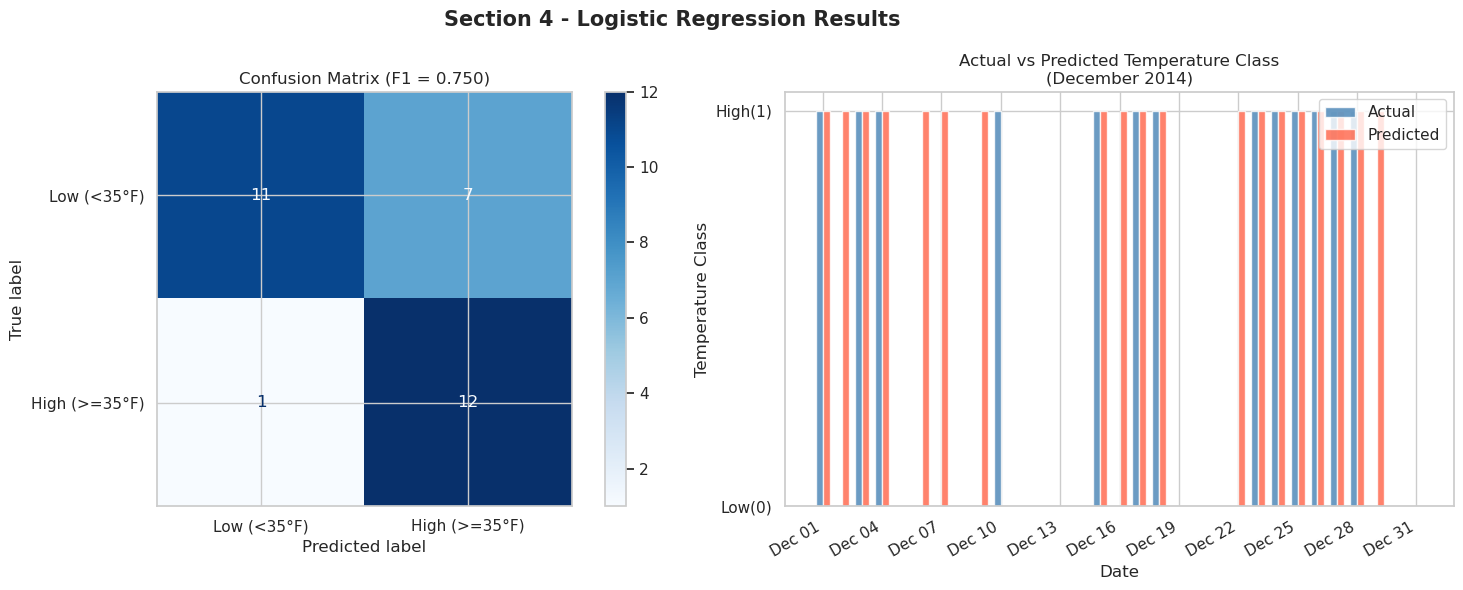

In [11]:
# Logistic Regression Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test_l, y_pred_log,
    display_labels=['Low (<35°F)', 'High (>=35°F)'],
    cmap='Blues', ax=axes[0])
axes[0].set_title(f'Confusion Matrix (F1 = {f1:.3f})')

# Plot 2: Actual vs Predicted class per day in December
y_test_l_vals = y_test_l.reset_index(drop=True).values
x_pos = np.arange(len(test))
w = 0.35
axes[1].bar(x_pos - w/2, y_test_l_vals, w, label='Actual', color='steelblue', alpha=0.8)
axes[1].bar(x_pos + w/2, y_pred_log,    w, label='Predicted', color='tomato', alpha=0.8)
axes[1].set_xticks(x_pos[::3])
axes[1].set_xticklabels(
    [pd.Timestamp(d).strftime('%b %d') for d in test['date'].values[::3]],
    rotation=30, ha='right')
axes[1].set_yticks([0, 1])
axes[1].set_yticklabels(['Low(0)', 'High(1)'])
axes[1].set_title('Actual vs Predicted Temperature Class\n(December 2014)')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Temperature Class')
axes[1].legend()

plt.suptitle('Section 4 - Logistic Regression Results', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# Logistic Regression Key Findings

1. **F1 Score = 0.750** - The model achieves reasonable classification performance using only weather features (excluding temperature itself).
2. **High temperature well detected** - Recall for High (>=35°F) is 0.92, meaning the model correctly identifies most warm days.
3. **Low temperature harder to classify** - Recall for Low (<35°F) is only 0.61, with 7 out of 18 low-temperature days misclassified as High.
4. **December is mostly High** - 13 out of 31 December days are High, consistent with the mild early-December temperatures in this dataset.

In [12]:
# CSV dump
log_csv = pd.DataFrame({
    'date': test['date'].dt.strftime('%Y-%m-%d'),
    'temperature_class': y_pred_log
})
log_csv.to_csv('logistic_regression_classifications.csv', index=False)
print("Saved: logistic_regression_classifications.csv")

Saved: logistic_regression_classifications.csv


In [13]:
# Section 5 - Device Usage Analysis

# Define Day (6AM-7PM) and Night (7PM-6AM)
energy_raw = energy.copy()
energy_raw['datetime'] = pd.to_datetime(energy_raw['Date & Time'])
energy_raw['hour'] = energy_raw['datetime'].dt.hour
energy_raw['period'] = np.where(
    (energy_raw['hour'] >= 6 ) & (energy_raw['hour'] < 19), 'Day', 'Night'
)

print("Period distribution:")
print(energy_raw['period'].value_counts())
print(energy_raw[['datetime', 'hour', 'period', 'AC [kW]', 'Washer [kW]']].head())

Period distribution:
period
Day      9490
Night    8030
Name: count, dtype: int64
             datetime  hour period   AC [kW]  Washer [kW]
0 2014-01-01 00:00:00     0  Night  0.000058     0.000126
1 2014-01-01 00:30:00     0  Night  0.001534     0.000043
2 2014-01-01 01:00:00     1  Night  0.001847     0.000044
3 2014-01-01 01:30:00     1  Night  0.001744     0.000059
4 2014-01-01 02:00:00     2  Night  0.000030     0.000119


In [14]:
# Aggregate mean usage by hour of day (full year)
hourly_avg = (energy_raw
             .groupby('hour')[['AC [kW]', 'Washer [kW]']]
             .mean()
             .reset_index())

# Aggregate mean usage by period (Day/Night)
period_avg = (energy_raw
             .groupby('period')[['AC [kW]', 'Washer [kW]']]
             .mean()
             .reset_index())

print("Mean usage by period:")
print(period_avg)

Mean usage by period:
  period   AC [kW]  Washer [kW]
0    Day  0.040263     0.004598
1  Night  0.146596     0.001258


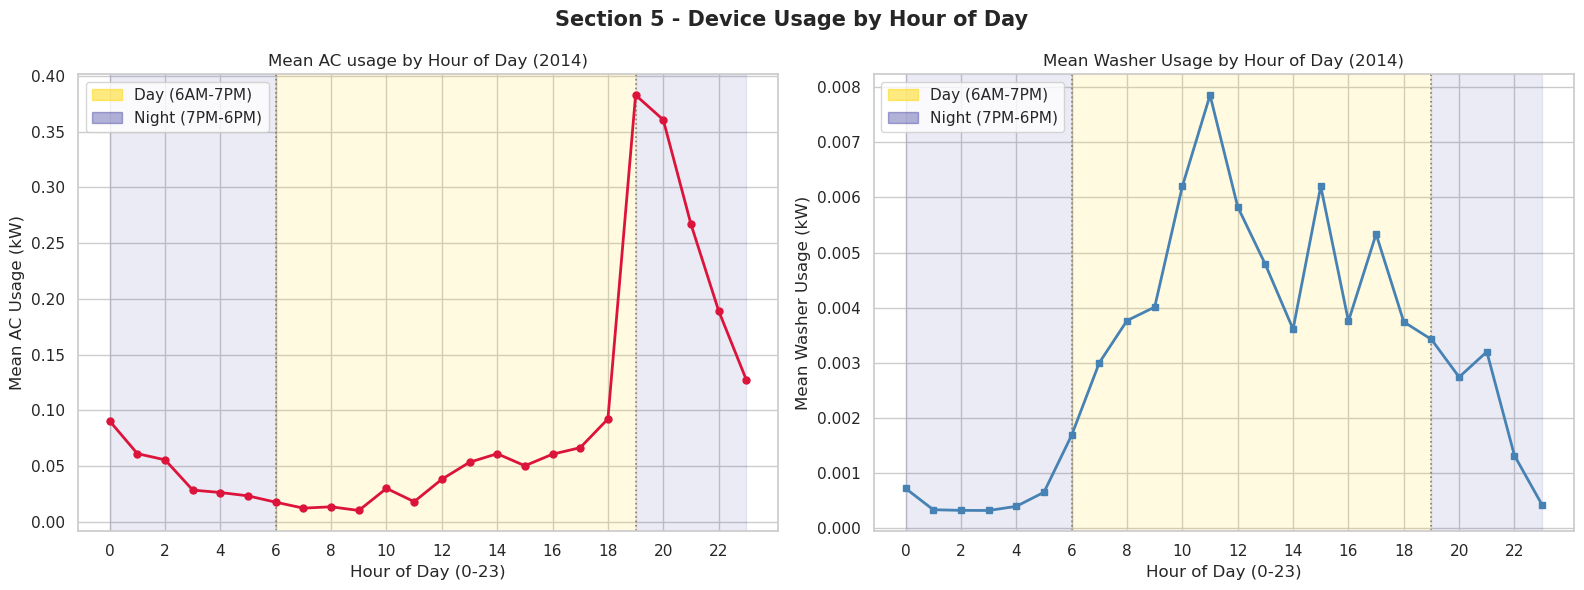

In [15]:
# Device Usage Analysis Visualization
fig, axes = plt.subplots(1, 2, figsize=(16,6))

#Shade Day/Night regions
for ax in axes:
    ax.axvspan(0, 6, alpha=0.08, color='navy')
    ax.axvspan(6, 19, alpha=0.12, color='gold')
    ax.axvspan(19, 23, alpha=0.08, color='navy')
    ax.axvline(x=6, color='gray', ls=':', lw=1.2)
    ax.axvline(x=19, color='gray', ls=':', lw=1.2)
    ax.set_xlabel('Hour of Day (0-23)')
    ax.set_xticks(range(0, 24, 2))

# Plot 1: AC hourly usage
axes[0].plot(hourly_avg['hour'], hourly_avg['AC [kW]'],
            color='crimson', marker='o', ms=5, lw=2)
axes[0].set_title('Mean AC usage by Hour of Day (2014)')
axes[0].set_ylabel('Mean AC Usage (kW)')

# Plot 2: Washer hourly usege 
axes[1].plot(hourly_avg['hour'], hourly_avg['Washer [kW]'],
            color='steelblue', marker='s', ms=5, lw=2)
axes[1].set_title('Mean Washer Usage by Hour of Day (2014)')
axes[1].set_ylabel('Mean Washer Usage (kW)')

#Add legend for Day/Night shading
day_patch = Patch(color='gold', alpha=0.5, label='Day (6AM-7PM)')
night_patch = Patch(color='navy', alpha=0.3, label='Night (7PM-6PM)')
for ax in axes:
    ax.legend(handles=[day_patch, night_patch])

plt.suptitle('Section 5 - Device Usage by Hour of Day', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# Device Usage Key Findings

1. **AC is predominantly used at night** - AC usage peaks at 7PM and remains high throughout the night. During the day, AC usage is minimal, suggesting the household relies on AC mainly for nighttime cooling.
2. **Washer is predominantly used during the day** - Washer usage peaks at 11AM and drops significantly after 7PM. This confirms the washer is a daytime appliance, consistent with typical household laundry routines.
3. **AC day vs night** - Mean AC usage at night (0.147 kW) is nearly 4x higher than during the day (0.040 kW).
4. **Washer day vs night** - Mean Washer usage during the day (0.005 kW) is nearly 4x higher than at night (0.001 kW).